In [1]:
from pygt3x.reader import FileReader
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import numpy as np
import pandas as pd
import plotly.express as px
from scipy.integrate import simpson
from scipy.signal import butter, filtfilt
import seaborn as sns
from datetime import datetime, timedelta
from tqdm.notebook import tqdm

In [2]:
def butter_bandpass_filter(data, lowcut=0.3, highcut=14.99, fs=30, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data, axis=0)

In [3]:
date_df = pd.read_csv("6MWD.csv")
date_df

,ID,Date,Time,Distance,Cohort,Datetime_EDT,Start,End
0,C01,6-18-2016,13:53,2147,Control,2016-06-18 13:53:00-04:00,1466257980,1466258340
1,C04,6-21-2016,14:36,1816,Control,2016-06-21 14:36:00-04:00,1466519760,1466520120
2,C10,6-27-2016,12:09,1766,Control,2016-06-27 12:09:00-04:00,1467029340,1467029700
3,C12,6-30-2016,11:46,2063,Control,2016-06-30 11:46:00-04:00,1467287160,1467287520
4,C29,7-15-2016,11:47,2478,Control,2016-07-15 11:47:00-04:00,1468583220,1468583580
5,C30,7-15-2016,11:34,1853,Control,2016-07-15 11:34:00-04:00,1468582440,1468582800
6,C35,7-25-2016,10:46,2460,Control,2016-07-25 10:46:00-04:00,1469443560,1469443920
7,C64,8-2-2017,12:56,2059,Control,2017-08-02 12:56:00-04:00,1501678560,1501678920
8,C69,11-02-2017,16:38,2055,Control,2017-11-02 16:38:00-04:00,1509640680,1509641040
9,C75,10-18-2018,15:36,1705,Control,2018-10-18 15:36:00-04:00,1539876960,1539877320


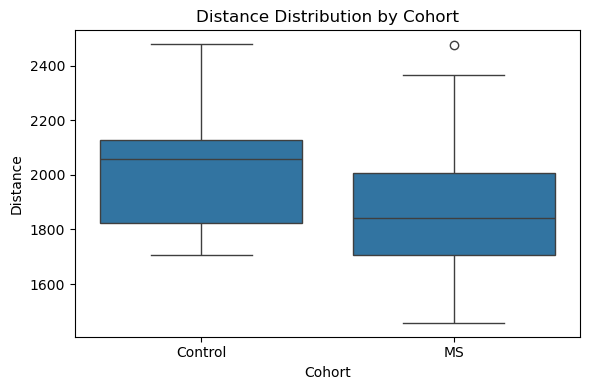

In [4]:
# Plot using seaborn
plt.figure(figsize=(6, 4))
sns.boxplot(data=date_df, x='Cohort', y='Distance')
plt.title("Distance Distribution by Cohort")
# plt.grid(True)
plt.tight_layout()
plt.show()

In [5]:
import os

folder_path = r"C:\6mw\Data"
files = [f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))]
files

['C01_(2016-06-18).gt3x',
 'C04_(2016-06-21).gt3x',
 'C10_(2016-06-27).gt3x',
 'C12_(2016-06-30).gt3x',
 'C29_(2016-07-15).gt3x',
 'C30_(2016-07-15).gt3x',
 'C35_(2016-07-25).gt3x',
 'C64_(2017-08-02).gt3x',
 'C69_(2017-11-02).gt3x',
 'C75_(2018-10-18).gt3x',
 'M50_(2023-10-19).gt3x',
 'M51_(2023-12-12).gt3x',
 'M52_(2024-02-08).gt3x',
 'M53_(2024-02-15).gt3x',
 'M54_(2024-03-21).gt3x',
 'M56_(2024-06-10).gt3x',
 'M57_(2024-06-20).gt3x',
 'M60_(2024-10-09).gt3x',
 'M61_(2024-12-17).gt3x',
 'M63_(2025-03-12).gt3x']

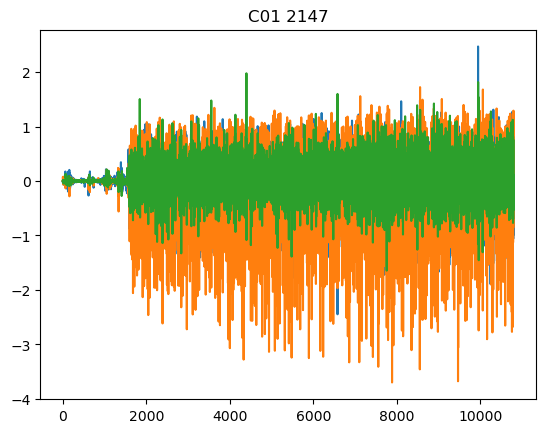

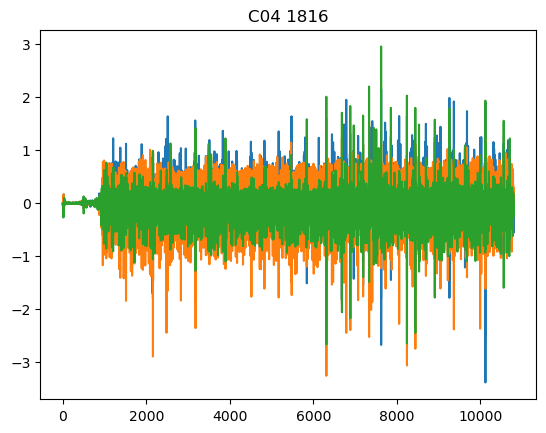

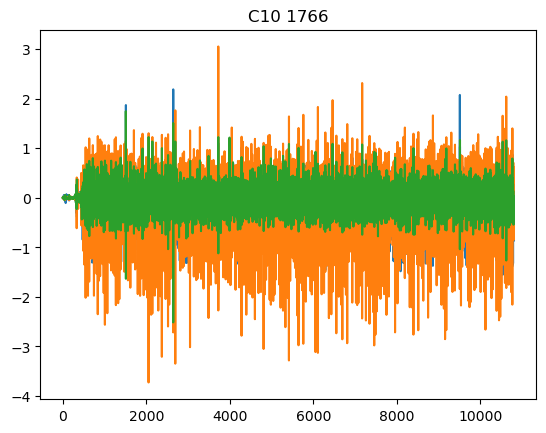

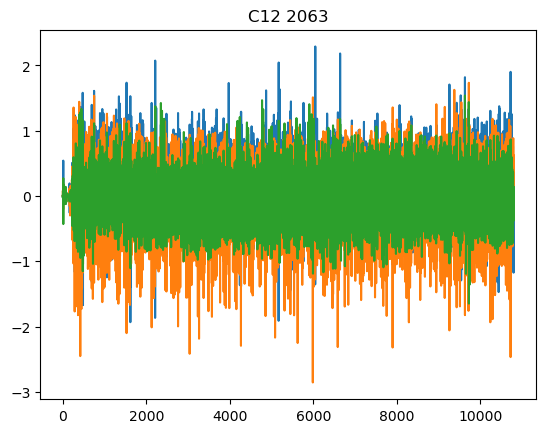

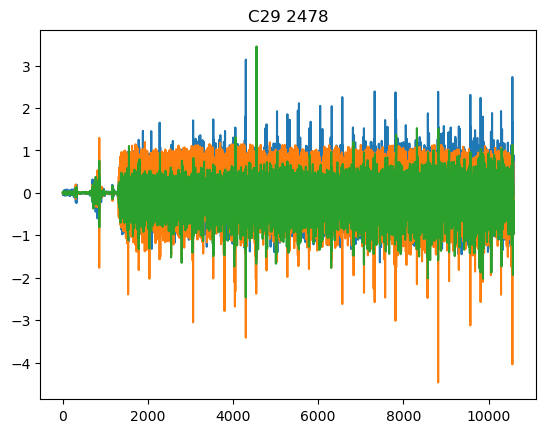

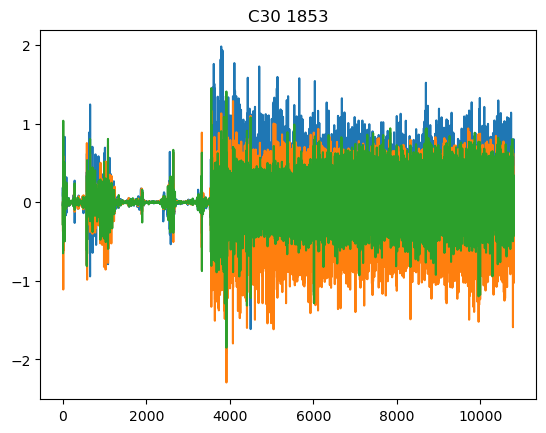

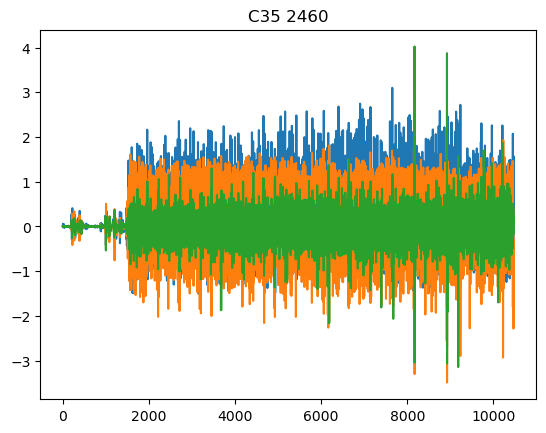

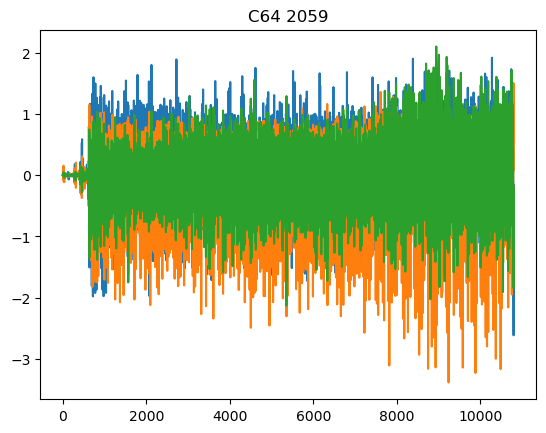

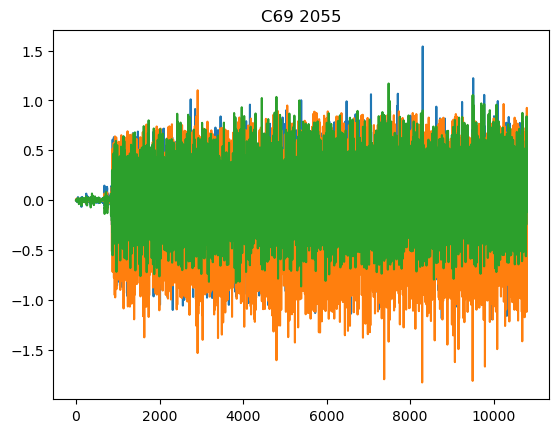

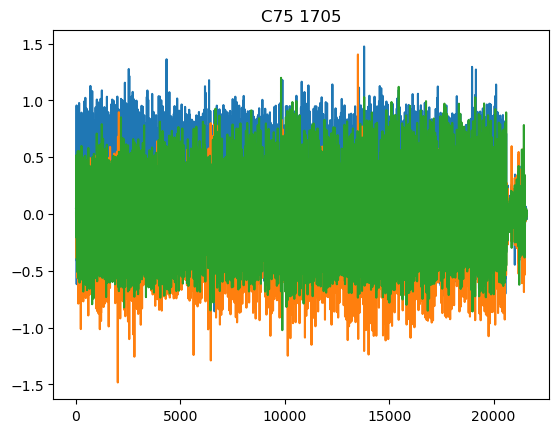

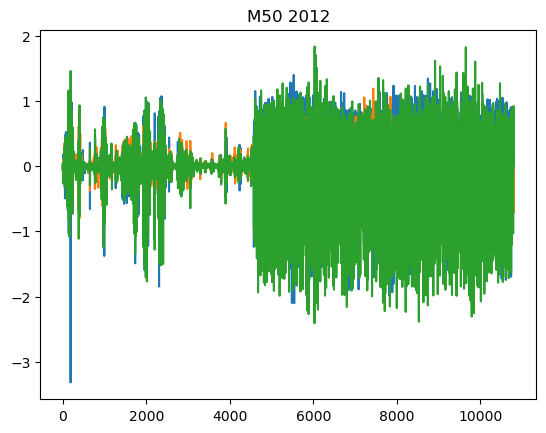

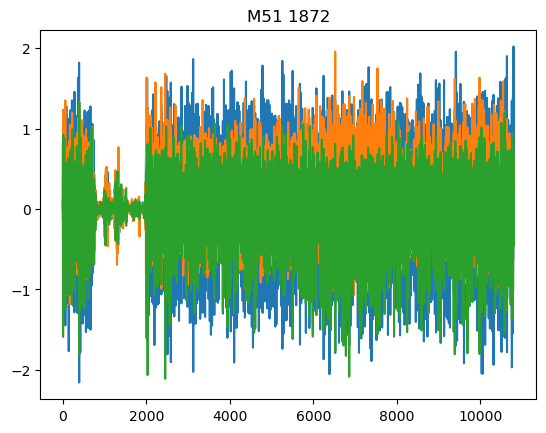

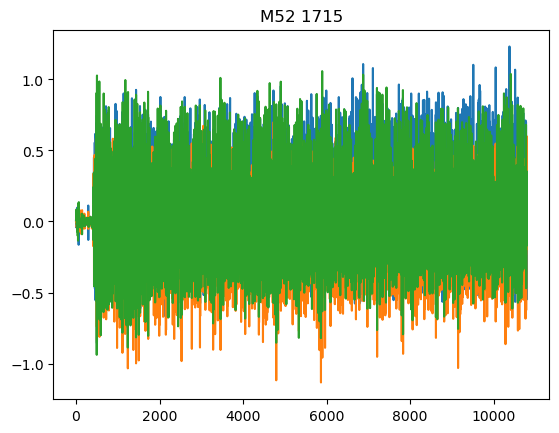

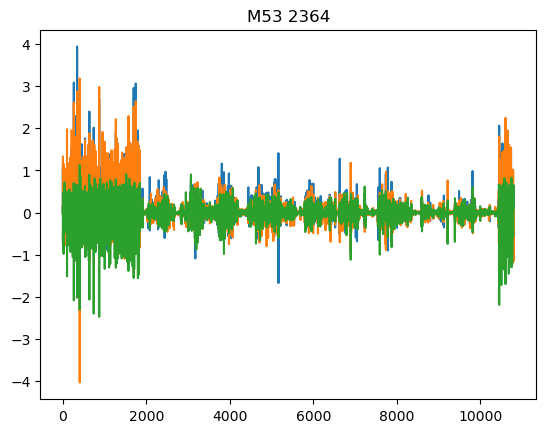

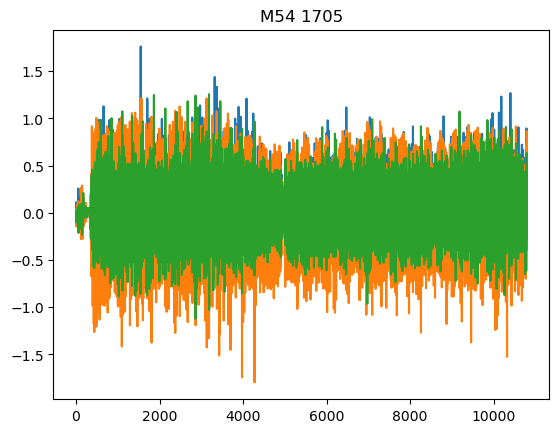

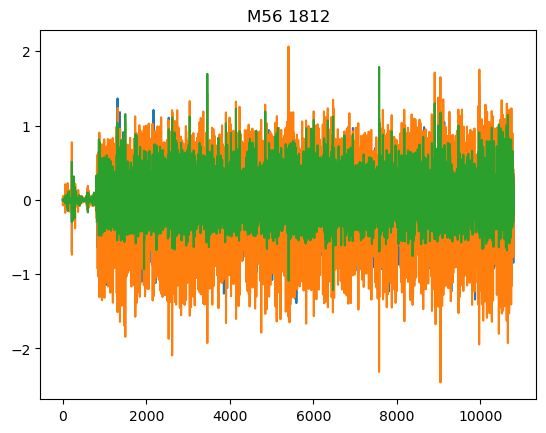

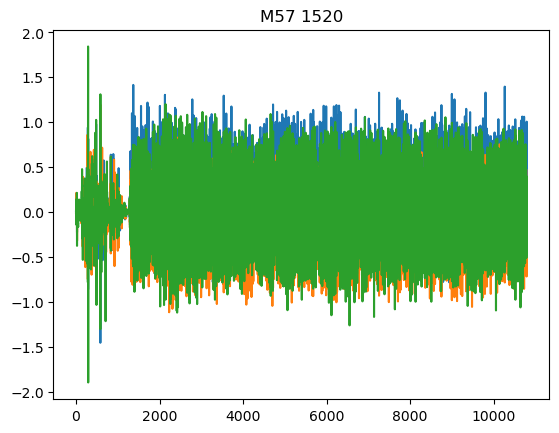

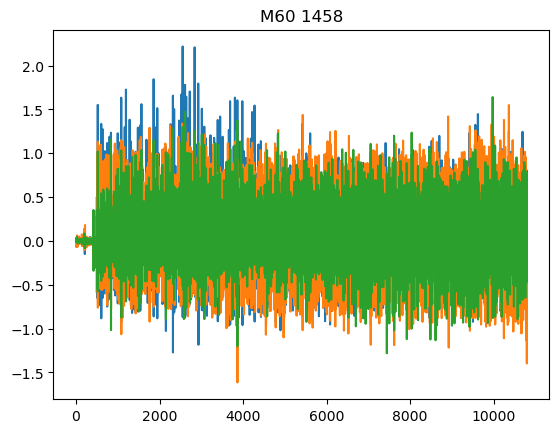

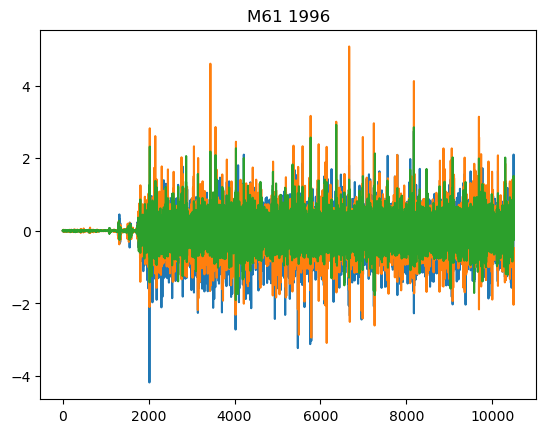

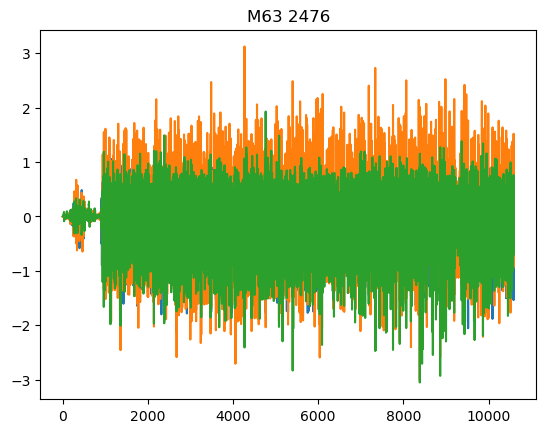

In [6]:
all_gaits = []
subids = []

for f in files:
    subid = f.split('_')[0]
    filename = os.path.join(r"C:\6mw\Data", f)
    
    # Read raw data and calibrate, then export to pandas data frame
    with FileReader(filename) as reader:
        df = reader.to_pandas()

    start_time = date_df.loc[date_df['ID'] == subid,'Start'].values[0]
    end_time = date_df.loc[date_df['ID'] == subid,'End'].values[0]
    dist = date_df.loc[date_df['ID'] == subid,'Distance'].values[0]

    gait_data = df[(df.index >= start_time) & (df.index <= end_time)]
    
    acc = gait_data.values[:,0:-1]
    acc = np.array(acc, dtype=np.float64)
    filtered_acc = butter_bandpass_filter(acc)

    all_gaits.append(filtered_acc)
    subids.append(subid)
    
    plt.figure()
    title_text = str(subid) + " " + str(dist)
    plt.title(title_text)
    plt.plot(filtered_acc[:,0])
    plt.plot(filtered_acc[:,1])
    plt.plot(filtered_acc[:,2])
    plt.show()

In [7]:
import numpy as np
from scipy.fft import rfft, rfftfreq
from scipy.signal import detrend

def compute_velocity(acc_data, dt=1/30.0):
    """
    Integrates acceleration to estimate velocity along each axis.
    Assumes constant sampling rate (default 50Hz).
    """
    return np.cumsum(acc_data * dt, axis=0)

def fuzzy_entropy(signal, m=2, r=0.2, n=2):
    """
    Computes fuzzy entropy of a 1D signal using exponential similarity kernel.
    m: embedding dimension, r: similarity threshold multiplier, n: fuzziness factor
    """
    N = len(signal)
    def _phi(m):
        x = np.array([signal[i:i+m] - np.mean(signal[i:i+m]) for i in range(N - m + 1)])
        dist = np.max(np.abs(x[:, None] - x[None, :]), axis=2)
        sim = np.exp(-(dist**n) / (r * np.std(signal))**n)
        return np.sum(sim) / ((N - m + 1)**2 - (N - m + 1))
    return np.log(_phi(m)) - np.log(_phi(m+1))

def fuzzy_entropy_velocity_features(acc_data):
    """
    Extracts fuzzy entropy of velocity (integrated acceleration) on each axis.
    Assumes acc_data has shape (T, 3) with axes: x=VT, y=ML, z=AP.
    """
    vel = compute_velocity(acc_data)
    feats = {
        'fuzzy_en_vt': fuzzy_entropy(vel[:, 0]),  # x-axis → Vertical
        'fuzzy_en_ml': fuzzy_entropy(vel[:, 1]),  # y-axis → Medio-Lateral
        'fuzzy_en_ap': fuzzy_entropy(vel[:, 2])   # z-axis → Antero-Posterior
    }
    return feats

def fft_resonance_features(acc_data, fs=30):
    """
    Extracts dominant resonance frequency and amplitude at peak for each axis.
    """
    features = {}
    labels = ['vt', 'ml', 'ap']  # mapped to x, y, z
    for i, label in enumerate(labels):
        signal = detrend(acc_data[:, i])
        fft_vals = np.abs(rfft(signal))
        freqs = rfftfreq(len(signal), 1/fs)
        peak_idx = np.argmax(fft_vals)
        features[f'resonant_freq_{label}'] = freqs[peak_idx]
        features[f'amplitude_at_peak_{label}'] = fft_vals[peak_idx]
    return features

def extract_all_features(acc_data, fs=30):
    """
    Extracts full feature set from 3-axis accelerometer signal.
    """
    fuzzy_feats = fuzzy_entropy_velocity_features(acc_data)
    fft_feats = fft_resonance_features(acc_data, fs=fs)
    return {**fuzzy_feats, **fft_feats}


In [8]:
from scipy.spatial.distance import pdist, squareform

# Define utility functions for time-domain and frequency-domain features
def jerk(acc, dt=1/30):
    """Sway jerkiness, time derivative of acceleration (d²a/dt²)."""
    dacc_dt = np.gradient(acc, dt, axis=0)
    jerk_sq = np.sum(dacc_dt**2, axis=1)
    return 0.5 * np.sum(jerk_sq) * dt

def dist(acc):
    """Mean distance from center (Euclidean norm) of trajectory."""
    return np.mean(np.linalg.norm(acc, axis=1))
    
def rms(acc):
    """Root mean square of acceleration (COP proxy)."""
    return np.sqrt(np.mean(np.square(acc), axis=0)).mean()

def path(acc):
    """Total sway path (cumulative distance)."""
    diff = np.diff(acc, axis=0)
    step_lengths = np.linalg.norm(diff, axis=1)
    return np.sum(step_lengths)

def displacement_range(acc):
    """Range of displacement (COP acceleration)."""
    return np.ptp(acc, axis=0).mean()

def mean_velocity(acc, dt=1/30):
    """Mean velocity from acceleration signal."""
    velocity = np.cumsum(acc, axis=0) * dt
    velocity_magnitude = np.linalg.norm(velocity, axis=1)
    return np.mean(velocity_magnitude)

def mean_frequency(path_length, dist_value, trial_duration):
    """Mean frequency (number of loops per second)."""
    return path_length / (2 * np.pi * dist_value * trial_duration)

def sway_area(acc, dt=1/30):
    """Sway area per unit time (approximated by polygon area)."""
    velocity = np.cumsum(acc, axis=0) * dt
    x, y = velocity[:, 0], velocity[:, 1]
    area = 0.5 * np.abs(np.dot(x, np.roll(y, 1)) - np.dot(y, np.roll(x, 1)))
    return area / (len(acc) * dt)

def total_power(acc, dt=1/30):
    """Total power of the signal (sum of squared FFT magnitudes)."""
    fft_vals = np.fft.rfft(acc, axis=0)
    power = np.sum(np.abs(fft_vals)**2, axis=0)
    return np.mean(power)

def power_frequencies(acc, dt=1/30):
    """Return F50, F95, CF, FD."""
    n = acc.shape[0]
    freqs = np.fft.rfftfreq(n, d=dt)
    fft_vals = np.abs(np.fft.rfft(acc, axis=0))**2
    power_spectrum = np.mean(fft_vals, axis=1)
    total_power_val = np.sum(power_spectrum)

    cum_power = np.cumsum(power_spectrum)
    f50 = freqs[np.searchsorted(cum_power, 0.5 * total_power_val)]
    f95 = freqs[np.searchsorted(cum_power, 0.95 * total_power_val)]
    cf = np.sum(freqs * power_spectrum) / total_power_val
    fd = np.sqrt(np.sum(((freqs - cf)**2) * power_spectrum) / total_power_val)

    return f50, f95, cf, fd


def approximate_entropy(U, m=2, r=None):
    """Approximate Entropy (ApEn) of a 1D signal."""
    U = np.array(U)
    N = len(U)
    if r is None:
        r = 0.2 * np.std(U)

    def _phi(m):
        x = np.array([U[i:i + m] for i in range(N - m + 1)])
        C = np.sum(np.max(np.abs(x[:, None] - x[None, :]), axis=2) <= r, axis=0) / (N - m + 1)
        return np.sum(np.log(C)) / (N - m + 1)

    return abs(_phi(m) - _phi(m + 1))

def lyapunov_exponent(signal, m=10, tau=1, fs=30.0):
    """Compute largest Lyapunov Exponent (Wolf algorithm inspired)."""
    signal = np.array(signal)
    N = len(signal)
    embedded = np.array([signal[i:i + m * tau:tau] for i in range(N - m * tau)])
    dists = squareform(pdist(embedded))
    np.fill_diagonal(dists, np.inf)
    nearest = np.argmin(dists, axis=1)
    d0 = np.linalg.norm(embedded[0] - embedded[nearest[0]])
    d = []
    for i in range(1, min(embedded.shape[0], 100)):
        j = nearest[i]
        if i + 1 < embedded.shape[0] and j + 1 < embedded.shape[0]:
            d.append(np.linalg.norm(embedded[i + 1] - embedded[j + 1]))
    d = np.array(d)
    d = d[d > 0]
    if len(d) == 0:
        return np.nan
    return np.mean(np.log(d / d0)) * fs

In [9]:
def compute_stats(data, prefix=""):
    """
    Compute key percentiles and std dev, with optional prefix for keys.
    """
    data = np.asarray(data)
    return {
        f"{prefix}P5": np.percentile(data, 5),
        f"{prefix}P25": np.percentile(data, 25),
        f"{prefix}Median": np.percentile(data, 50),
        f"{prefix}P75": np.percentile(data, 75),
        f"{prefix}P95": np.percentile(data, 95),
        f"{prefix}StdDev": np.std(data, ddof=1)
    }

In [41]:
all_subs = []
for g, s in zip(all_gaits, subids):

    print(s)
    
    j = []
    d = []
    r = []
    p = []
    dis = []
    mv = []
    mf = []
    sa = []
    tp = []
    pf1 = []
    pf2 = []
    pf3 = []
    pf4 = []
    ae = []
    le = []

    fuzzy_en_vt = []
    fuzzy_en_ml = []
    fuzzy_en_ap = []
    resonant_freq_vt = []
    amplitude_at_peak_vt = []
    resonant_freq_ml = []
    amplitude_at_peak_ml = []
    resonant_freq_ap = []
    amplitude_at_peak_ap = []
    
    for start in range(0, g.shape[0] - 1800 + 1, 1800):
        end = start + 1800
        acc = g[start:end]

        j.append(jerk(acc))
        d.append(dist(acc))
        r.append(rms(acc))
        p.append(path(acc))
        dis.append(displacement_range(acc))
        mv.append(mean_velocity(acc))
        mf.append(mean_frequency(path(acc), dist(acc), trial_duration=1.0))
        sa.append(sway_area(acc))
        tp.append(total_power(acc))

        p1, p2, p3, p4 = power_frequencies(acc)
        pf1.append(p1)
        pf2.append(p2)
        pf3.append(p3)
        pf4.append(p4)

        acc_magnitude = np.linalg.norm(acc, axis=1)
        ae.append(approximate_entropy(acc_magnitude))
        le.append(lyapunov_exponent(acc_magnitude))

        # sensor_ft = extract_all_features(acc)
        # fuzzy_en_vt.append(sensor_ft['fuzzy_en_vt'])
        # fuzzy_en_ml.append(sensor_ft['fuzzy_en_ml'])
        # fuzzy_en_ap.append(sensor_ft['fuzzy_en_ap'])

        # resonant_freq_vt.append(sensor_ft['resonant_freq_vt'])
        # resonant_freq_ml.append(sensor_ft['resonant_freq_ml'])
        # resonant_freq_ap.append(sensor_ft['resonant_freq_ap'])

        # amplitude_at_peak_vt.append(sensor_ft['amplitude_at_peak_vt'])
        # amplitude_at_peak_ml.append(sensor_ft['amplitude_at_peak_ml'])
        # amplitude_at_peak_ap.append(sensor_ft['amplitude_at_peak_ap'])
        

    jj = compute_stats(j, prefix="jerk")
    dd = compute_stats(j, prefix="dist")
    rr = compute_stats(j, prefix="rms")
    pp = compute_stats(j, prefix="path")

    dds = compute_stats(dis, prefix="dis_range")
    mvmv = compute_stats(mv, prefix="mean_velcoity")
    mfmf = compute_stats(mf, prefix="mean_freq")
    sasa = compute_stats(sa, prefix="sway_area")

    tptp = compute_stats(dis, prefix="total_power")
    p1p1 = compute_stats(pf1, prefix="f50")
    p2p2 = compute_stats(pf2, prefix="f95")
    p3p3 = compute_stats(pf3, prefix="cf")
    p4p4 = compute_stats(pf3, prefix="fd")

    aeae = compute_stats(ae, prefix="AE")
    lele = compute_stats(le, prefix="LE")

    # fvt = compute_stats(fuzzy_en_vt, prefix="VI_vt")
    # fml = compute_stats(fuzzy_en_ml, prefix="VI_ml")
    # fap = compute_stats(fuzzy_en_ap, prefix="VI_ap")

    # rvt = compute_stats(resonant_freq_vt, prefix="RF_vt")
    # rml = compute_stats(resonant_freq_ml, prefix="RF_ml")
    # rap = compute_stats(resonant_freq_ap, prefix="RF_ap")

    # ampvt = compute_stats(amplitude_at_peak_vt, prefix="Amp_vt")
    # ampml = compute_stats(amplitude_at_peak_ml, prefix="Amp_ml")
    # ampap = compute_stats(amplitude_at_peak_ap, prefix="Amp_ap")

    combined_df = pd.DataFrame([{**jj, **dd, **rr, **pp, **dds, **mvmv, **mfmf, **sasa, **tptp, **p1p1, **p2p2, **p3p3, **p4p4, **aeae, **lele}])
                                # **fvt, **fml, **fap, **rvt, **rml, **rap, **ampvt, **ampml, **ampap
    all_subs.append(combined_df)

alldf = pd.concat(all_subs, axis=0)
alldf

C01
C04
C10
C12
C29
C30
C35
C64
C69
C75
M50
M51
M52
M53
M54
M56
M57
M60
M61
M63


,jerkP5,jerkP25,jerkMedian,jerkP75,jerkP95,jerkStdDev,distP5,distP25,distMedian,distP75,...,AEMedian,AEP75,AEP95,AEStdDev,LEP5,LEP25,LEMedian,LEP75,LEP95,LEStdDev
0,2816.308085,8873.116088,10167.882737,11568.798892,11936.500793,4145.804561,2816.308085,8873.116088,10167.882737,11568.798892,...,1.528273,1.566126,1.616471,0.480997,2.097303,3.807335,4.916447,10.684086,16.031748,6.048445
0,1668.055266,2851.378728,3406.740287,3810.273229,4288.605168,1082.831073,1668.055266,2851.378728,3406.740287,3810.273229,...,1.433366,1.465976,1.482047,0.285236,-18.489462,1.670087,7.821667,14.116926,24.816445,18.050869
0,4663.752156,6149.036191,6217.495766,6602.235076,6817.268705,967.200730,4663.752156,6149.036191,6217.495766,6602.235076,...,1.487961,1.492562,1.500643,0.139440,-3.301275,0.249021,8.489829,10.615886,20.259310,9.856379
0,6556.007714,6763.143647,7183.811346,7529.816809,7775.595969,518.388895,6556.007714,6763.143647,7183.811346,7529.816809,...,1.737097,1.740777,1.779151,0.098050,-1.200720,2.539302,3.903288,10.717941,34.773541,16.266574
0,2548.741846,6015.374536,8231.519195,8278.034786,9684.615635,3221.183268,2548.741846,6015.374536,8231.519195,8278.034786,...,1.723733,1.728226,1.756068,0.519065,-4.595986,2.268752,2.997756,6.599142,13.332720,7.719909
0,463.195899,1562.592861,4845.537417,5123.494381,6554.768283,2699.482017,463.195899,1562.592861,4845.537417,5123.494381,...,1.656731,1.693650,1.712394,0.622818,-9.876880,0.520711,9.791536,11.814112,19.771329,12.182423
0,3018.335973,8670.643589,9969.231696,10696.510813,11641.218226,4060.058911,3018.335973,8670.643589,9969.231696,10696.510813,...,1.729236,1.736474,1.745135,0.592091,-28.420012,-3.177973,4.943536,8.115765,22.893901,22.432971
0,7060.193159,8851.856635,10007.661966,12299.782235,13378.638556,2638.250048,7060.193159,8851.856635,10007.661966,12299.782235,...,1.658325,1.674640,1.715403,0.220521,-11.435214,-3.326988,2.438739,10.426911,13.908077,10.763495
0,1935.916801,3312.723734,3657.946549,3769.839518,3909.436744,910.630625,1935.916801,3312.723734,3657.946549,3769.839518,...,1.716921,1.730199,1.741650,0.351299,0.733034,9.100120,13.314116,17.137694,18.585820,7.796305
0,1039.001816,1313.299620,1357.972054,1454.221883,1565.779812,211.521338,1039.001816,1313.299620,1357.972054,1454.221883,...,1.364819,1.383652,1.398244,0.102848,-6.403073,0.378819,7.340812,17.599879,21.995847,10.728497


In [42]:
alldf.reset_index(drop=True, inplace=True)
alldf['Cohort'] = date_df['Cohort']
alldf['Distance'] = date_df['Distance']
alldf

,jerkP5,jerkP25,jerkMedian,jerkP75,jerkP95,jerkStdDev,distP5,distP25,distMedian,distP75,...,AEP95,AEStdDev,LEP5,LEP25,LEMedian,LEP75,LEP95,LEStdDev,Cohort,Distance
0,2816.308085,8873.116088,10167.882737,11568.798892,11936.500793,4145.804561,2816.308085,8873.116088,10167.882737,11568.798892,...,1.616471,0.480997,2.097303,3.807335,4.916447,10.684086,16.031748,6.048445,Control,2147
1,1668.055266,2851.378728,3406.740287,3810.273229,4288.605168,1082.831073,1668.055266,2851.378728,3406.740287,3810.273229,...,1.482047,0.285236,-18.489462,1.670087,7.821667,14.116926,24.816445,18.050869,Control,1816
2,4663.752156,6149.036191,6217.495766,6602.235076,6817.268705,967.200730,4663.752156,6149.036191,6217.495766,6602.235076,...,1.500643,0.139440,-3.301275,0.249021,8.489829,10.615886,20.259310,9.856379,Control,1766
3,6556.007714,6763.143647,7183.811346,7529.816809,7775.595969,518.388895,6556.007714,6763.143647,7183.811346,7529.816809,...,1.779151,0.098050,-1.200720,2.539302,3.903288,10.717941,34.773541,16.266574,Control,2063
4,2548.741846,6015.374536,8231.519195,8278.034786,9684.615635,3221.183268,2548.741846,6015.374536,8231.519195,8278.034786,...,1.756068,0.519065,-4.595986,2.268752,2.997756,6.599142,13.332720,7.719909,Control,2478
5,463.195899,1562.592861,4845.537417,5123.494381,6554.768283,2699.482017,463.195899,1562.592861,4845.537417,5123.494381,...,1.712394,0.622818,-9.876880,0.520711,9.791536,11.814112,19.771329,12.182423,Control,1853
6,3018.335973,8670.643589,9969.231696,10696.510813,11641.218226,4060.058911,3018.335973,8670.643589,9969.231696,10696.510813,...,1.745135,0.592091,-28.420012,-3.177973,4.943536,8.115765,22.893901,22.432971,Control,2460
7,7060.193159,8851.856635,10007.661966,12299.782235,13378.638556,2638.250048,7060.193159,8851.856635,10007.661966,12299.782235,...,1.715403,0.220521,-11.435214,-3.326988,2.438739,10.426911,13.908077,10.763495,Control,2059
8,1935.916801,3312.723734,3657.946549,3769.839518,3909.436744,910.630625,1935.916801,3312.723734,3657.946549,3769.839518,...,1.741650,0.351299,0.733034,9.100120,13.314116,17.137694,18.585820,7.796305,Control,2055
9,1039.001816,1313.299620,1357.972054,1454.221883,1565.779812,211.521338,1039.001816,1313.299620,1357.972054,1454.221883,...,1.398244,0.102848,-6.403073,0.378819,7.340812,17.599879,21.995847,10.728497,Control,1705


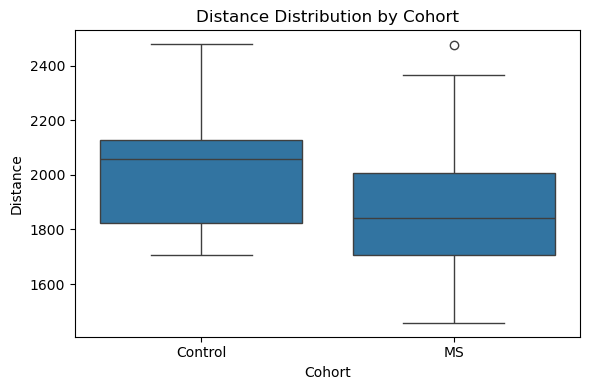

In [43]:
# Plot using seaborn
plt.figure(figsize=(6, 4))
sns.boxplot(data=alldf, x='Cohort', y='Distance')
plt.title("Distance Distribution by Cohort")
# plt.grid(True)
plt.tight_layout()
plt.show()

In [44]:
def correlation_feature_selection(df, threshold=0.9):
    """
    Drops features with high correlation (greater than threshold).
    Keeps only one feature from each correlated group.
    Returns a reduced DataFrame.
    """
    corr_matrix = df.corr().abs()
    upper_triangle = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    high_corr_pairs = (corr_matrix.where(upper_triangle) > threshold)

    to_drop = [column for column in high_corr_pairs.columns if any(high_corr_pairs[column])]
    return df.drop(columns=to_drop), to_drop

In [45]:
allXdf = alldf.loc[:,'jerkP5':'LEStdDev']
Xdf, dropped_columns = correlation_feature_selection(allXdf, threshold=0.9)
Xdf

,jerkP5,jerkP25,jerkStdDev,dis_rangeP5,dis_rangeP25,dis_rangeStdDev,mean_velcoityP5,mean_velcoityP25,mean_velcoityP95,mean_freqP5,...,cfStdDev,AEP5,AEP25,AEMedian,LEP5,LEP25,LEMedian,LEP75,LEP95,LEStdDev
0,2816.308085,8873.116088,4145.804561,2.409874,3.211727,0.786598,0.031400,0.062392,0.091930,274.771248,...,0.238096,0.668315,1.524019,1.528273,2.097303,3.807335,4.916447,10.684086,16.031748,6.048445
1,1668.055266,2851.378728,1082.831073,2.174368,2.693017,1.161655,0.040734,0.041545,0.057180,283.720911,...,0.419207,0.915623,1.412410,1.433366,-18.489462,1.670087,7.821667,14.116926,24.816445,18.050869
2,4663.752156,6149.036191,967.200730,3.030178,3.345055,0.483919,0.030945,0.038676,0.046328,313.473262,...,0.100884,1.229307,1.475368,1.487961,-3.301275,0.249021,8.489829,10.615886,20.259310,9.856379
3,6556.007714,6763.143647,518.388895,2.902356,3.274758,0.292455,0.045503,0.051244,0.067111,289.241402,...,0.357176,1.554133,1.689412,1.737097,-1.200720,2.539302,3.903288,10.717941,34.773541,16.266574
4,2548.741846,6015.374536,3221.183268,2.933724,3.297050,0.905780,0.030550,0.042831,0.068343,258.086519,...,0.400908,0.788696,1.682014,1.723733,-4.595986,2.268752,2.997756,6.599142,13.332720,7.719909
5,463.195899,1562.592861,2699.482017,2.011076,2.186750,0.570434,0.021448,0.035247,0.068433,271.022068,...,0.549048,0.403016,0.933873,1.656731,-9.876880,0.520711,9.791536,11.814112,19.771329,12.182423
6,3018.335973,8670.643589,4060.058911,2.871333,3.304046,1.253406,0.028185,0.056638,0.072594,251.892785,...,0.235224,0.658088,1.684467,1.729236,-28.420012,-3.177973,4.943536,8.115765,22.893901,22.432971
7,7060.193159,8851.856635,2638.250048,3.224407,3.268267,0.494201,0.045729,0.053469,0.096991,278.435930,...,0.164104,1.253578,1.621636,1.658325,-11.435214,-3.326988,2.438739,10.426911,13.908077,10.763495
8,1935.916801,3312.723734,910.630625,1.892509,2.079973,0.222934,0.028940,0.047206,0.057153,241.626808,...,0.102576,1.072717,1.703117,1.716921,0.733034,9.100120,13.314116,17.137694,18.585820,7.796305
9,1039.001816,1313.299620,211.521338,1.620769,1.682753,0.201245,0.078206,0.086941,0.130832,131.036807,...,0.041951,1.181831,1.339389,1.364819,-6.403073,0.378819,7.340812,17.599879,21.995847,10.728497


In [46]:
from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier

y = alldf['Cohort']

# Encode class labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Initialize Leave-One-Out CV
loo = LeaveOneOut()
y_true, y_pred = [], []
feature_importances = np.zeros(Xdf.shape[1])

# Run LOOCV with XGBoost
for train_index, test_index in loo.split(Xdf):
    X_train, X_test = Xdf.iloc[train_index], Xdf.iloc[test_index]
    y_train, y_test = y_encoded[train_index], y_encoded[test_index]
    
    model = XGBClassifier()
    # model = RandomForestClassifier()
    model.fit(X_train, y_train)
    
    y_pred.append(model.predict(X_test)[0])
    y_true.append(y_test[0])
    
    feature_importances += model.feature_importances_

# Normalize feature importances
feature_importances /= len(Xdf)

# Accuracy
accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(y_true, y_pred, average='binary', pos_label=1)
recall = recall_score(y_true, y_pred, average='binary', pos_label=1)
f1 = f1_score(y_true, y_pred, average='binary', pos_label=1)

print(f"Accuracy: {accuracy*100:.2f}%")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# Convert feature importances to DataFrame
feature_importance_df = pd.DataFrame({
    'Feature': Xdf.columns,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

Accuracy: 80.00%
Precision: 0.7500
Recall: 0.9000
F1 Score: 0.8182


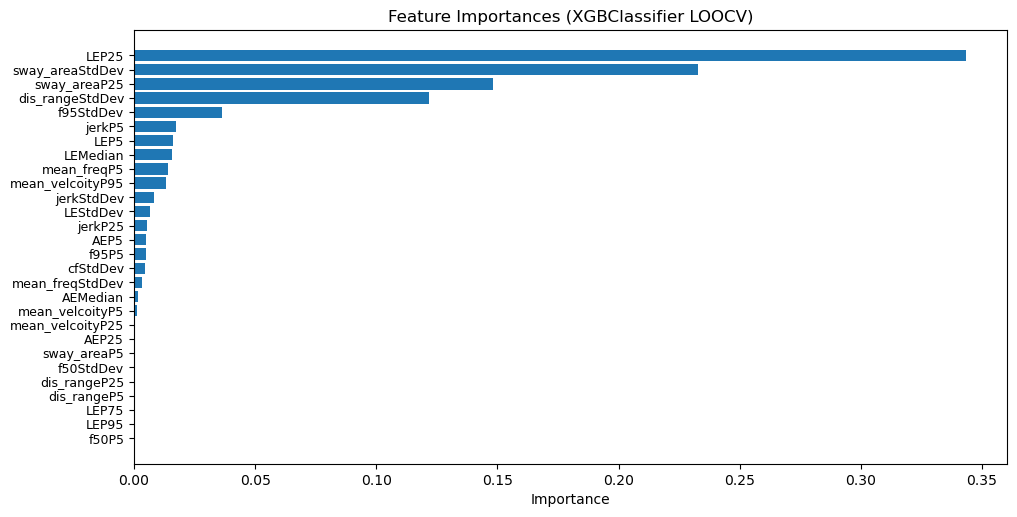

In [47]:
plt.figure(figsize=(10, 5))
bars = plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])

# Manually set yticks with more spacing
plt.yticks(ticks=np.arange(len(feature_importance_df)), 
           labels=feature_importance_df['Feature'], 
           fontsize=9)

plt.gca().invert_yaxis()
plt.xlabel('Importance')
plt.title('Feature Importances (XGBClassifier LOOCV)')
plt.tight_layout(pad=0.1)  # Increase padding around the layout
plt.show()

In [32]:
from scipy.stats import (
    ttest_ind, ttest_rel,
    shapiro, levene,
    mannwhitneyu, wilcoxon
)

def compare_columns(df, col1, col2, paired=False, alpha=0.05):
    """
    Performs t-test or appropriate non-parametric test between two columns,
    with normality and variance assumption checks.
    """
    x, y = df[col1].dropna(), df[col2].dropna()

    # Shapiro-Wilk Normality Test
    p_norm_x = shapiro(x).pvalue
    p_norm_y = shapiro(y).pvalue
    normal_x = p_norm_x > alpha
    normal_y = p_norm_y > alpha

    # Levene’s Test for equal variances (only applies if not paired)
    equal_var = True
    if not paired:
        p_levene = levene(x, y).pvalue
        equal_var = p_levene > alpha

    # Choose and run test
    if paired:
        if normal_x and normal_y:
            stat, pval = ttest_rel(x, y)
            test_used = "Paired t-test"
        else:
            stat, pval = wilcoxon(x, y)
            test_used = "Wilcoxon signed-rank test (non-parametric)"
    else:
        if normal_x and normal_y:
            stat, pval = ttest_ind(x, y, equal_var=equal_var)
            test_used = "Unpaired t-test"
        else:
            stat, pval = mannwhitneyu(x, y, alternative="two-sided")
            test_used = "Mann-Whitney U test (non-parametric)"

    return {
        "Test": test_used,
        "stat": stat,
        "p-value": pval,
        "Normality_col1": normal_x,
        "Normality_col2": normal_y,
        "Equal_Variance": equal_var if not paired else "N/A"
    }

In [48]:
for col_name, col_data in alldf.items():
    if col_name != 'Cohort':

        cdf = pd.DataFrame()
        cdf['Control'] = col_data[alldf['Cohort'] == 'Control'].values
        cdf['MS'] = col_data[alldf['Cohort'] == 'MS'].values
        rd = compare_columns(cdf, 'Control', 'MS')

        if rd["p-value"] < 0.05:
            print(f"{col_name}, stat: {rd["stat"]}, p-value: {rd["p-value"]}")

sway_areaMedian, stat: 2.520881877638317, p-value: 0.02135928584652722
sway_areaP75, stat: 2.56783658110631, p-value: 0.019363274659002654
sway_areaP95, stat: 82.0, p-value: 0.017257456083119765
sway_areaStdDev, stat: 2.6608572045357946, p-value: 0.018342409928738528
LEP25, stat: 2.946766633896081, p-value: 0.008626889553890288
LEMedian, stat: 2.79879161688799, p-value: 0.011867411626267248


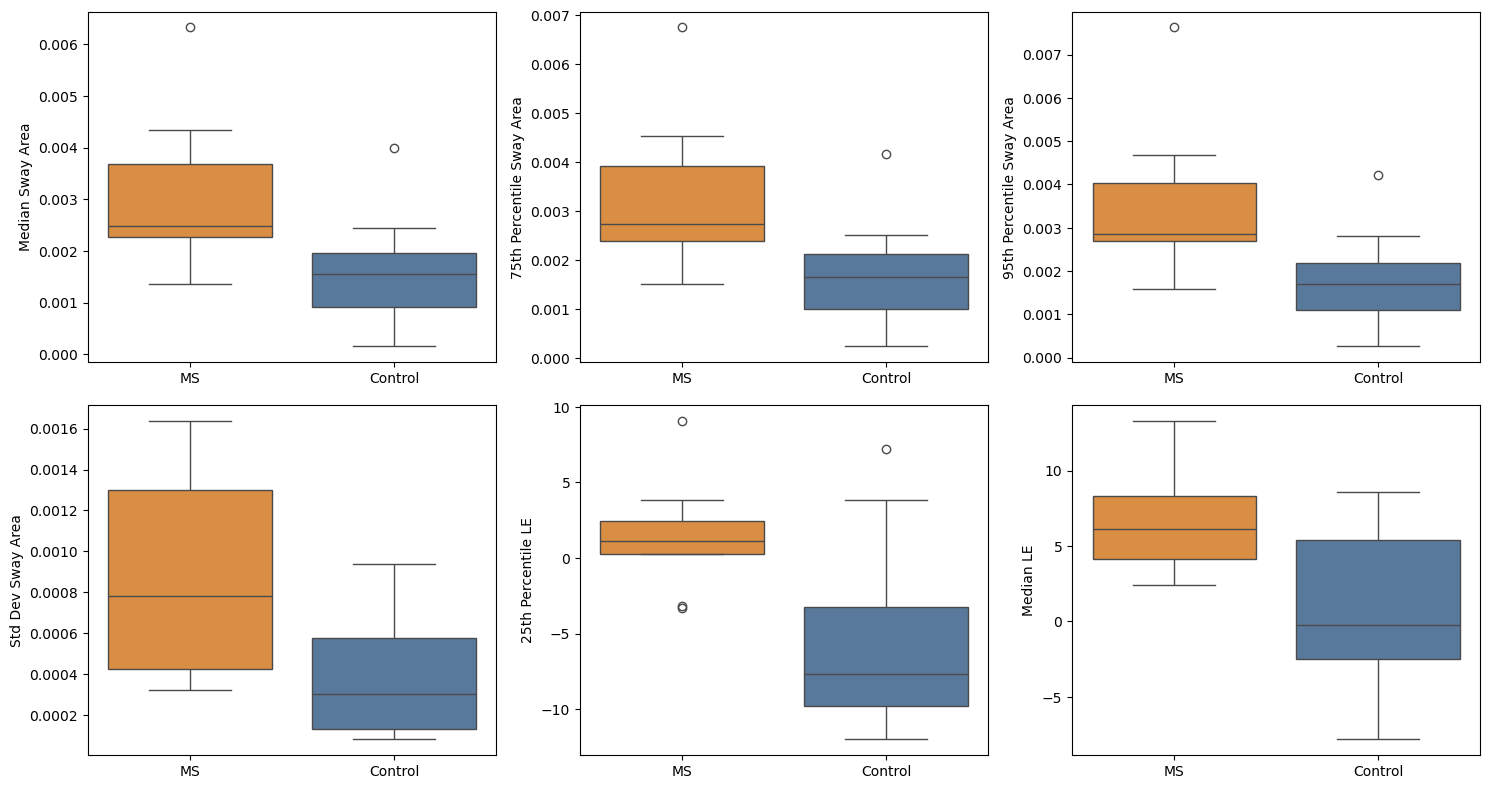

In [51]:
# Features and titles (fixed comma between titles)
features = ['sway_areaMedian', 'sway_areaP75', 'sway_areaP95', 'sway_areaStdDev', 'LEP25', 'LEMedian']
titles = ['Median Sway Area', '75th Percentile Sway Area', '95th Percentile Sway Area',
          'Std Dev Sway Area', '25th Percentile LE', 'Median LE']

palette = {'Control': '#4E79A7', 'MS': '#F28E2B'}

# Set up 2-row, 3-column grid
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 8), sharey=False)
axes = axes.flatten()  # flatten to iterate easily

plot_df = alldf.copy()
plot_df['Cohort'] = plot_df['Cohort'].map({'Control': 'MS', 'MS': 'Control'})

# Generate plots
for ax, feat, title in zip(axes, features, titles):
    sns.boxplot(data=plot_df, x='Cohort', y=feat, hue='Cohort', palette=palette, legend=False, ax=ax)
    ax.set_xlabel("")
    ax.set_ylabel(title)

plt.tight_layout()
plt.show()

MAE: 207.27196044921874 , Correlation: 0.6044593718844857 , p-value: 0.004757658616294972 , R^2: 0.222353204933739


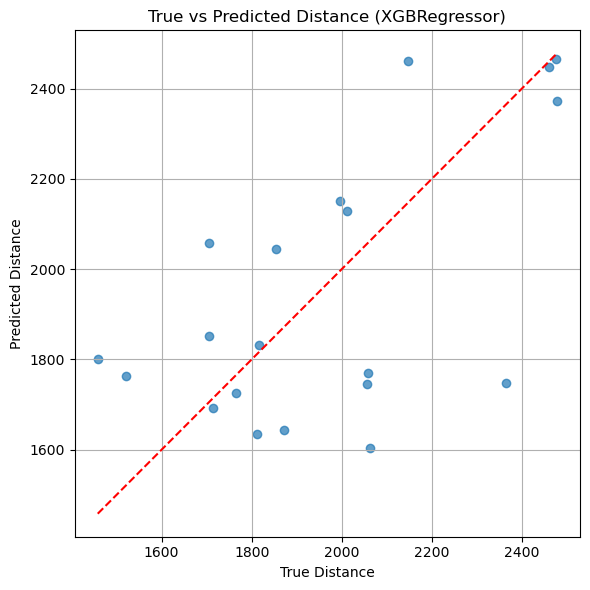

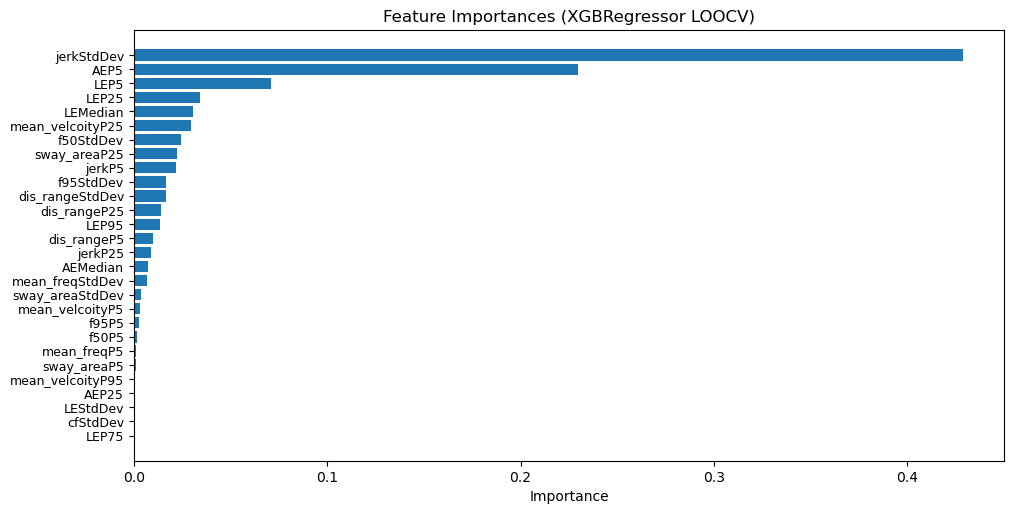

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_absolute_error, r2_score
from scipy.stats import spearmanr
from scipy.stats import pearsonr
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor

# Assuming Xdf and alldf are already defined and available in the environment

# Extract the target variable
y = alldf['Distance'].values
X = Xdf.values

# Initialize Leave-One-Out CV
loo = LeaveOneOut()
y_true, y_pred = [], []
feature_importances = np.zeros(X.shape[1])

# Run LOOCV with XGBRegressor
for train_index, test_index in loo.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    model = XGBRegressor()
    # model = RandomForestRegressor()
    model.fit(X_train, y_train)
    
    y_pred.append(model.predict(X_test)[0])
    y_true.append(y_test[0])
    
    feature_importances += model.feature_importances_

# Normalize feature importances
feature_importances /= len(X)

# Compute evaluation metrics
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)
# corr, _ = spearmanr(y_true, y_pred)
corr, p_value = pearsonr(y_true, y_pred)

print('MAE:',mae,', Correlation:',corr, ', p-value:',p_value, ', R^2:', r2)

# Convert feature importances to DataFrame
feature_importance_df = pd.DataFrame({
    'Feature': Xdf.columns,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

# Plot y_true vs y_pred
plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, alpha=0.7)
plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], '--', color='red')
plt.xlabel('True Distance')
plt.ylabel('Predicted Distance')
plt.title('True vs Predicted Distance (XGBRegressor)')
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
bars = plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])

# Manually set yticks with more spacing
plt.yticks(ticks=np.arange(len(feature_importance_df)), 
           labels=feature_importance_df['Feature'], 
           fontsize=9)

plt.gca().invert_yaxis()
plt.xlabel('Importance')
plt.title('Feature Importances (XGBRegressor LOOCV)')
plt.tight_layout(pad=0.2)  # Increase padding around the layout
plt.show()

In [48]:
pd.set_option('display.max_rows', None) 

# Compute correlation with 'Distance'
corr_matrix = alldf.corr(numeric_only=True)
distance_corr = corr_matrix[['Distance']].drop('Distance')
dc = distance_corr.sort_values(by='Distance', ascending=False)
dc

,Distance
total_powerP95,0.673440
dis_rangeP95,0.673440
jerkStdDev,0.631272
rmsStdDev,0.631272
distStdDev,0.631272
pathStdDev,0.631272
rmsP95,0.605714
pathP95,0.605714
distP95,0.605714
jerkP95,0.605714
